# 05 Evaluation Design: 品質ゲートの設計

**目的**: 実用に耐えうるモデルの定量的基準（品質ゲート）を設計し、
自動評価フレームワーク（`src/apps/evaluate_and_promote.py`）の根拠を示す。

**設計する品質ゲート**:
1. MAE < threshold（ターゲット別に定義）
2. RMSE < MAE_threshold × 1.5
3. |bias| < MAE_threshold × 0.5
4. MAE < baseline（無補正の MAE より良い）

4つ全て合格 → `evaluated_successful = "1"` → 推論に使用可能

## Setup & データ準備

In [9]:
import sys
from pathlib import Path

_nb_dir = next(p for p in [Path("."), Path("notebooks")] if (p / "utils.py").exists())
sys.path.insert(0, str(_nb_dir.resolve()))

from utils import ERROR_UNITS, load_base_dataset, get_feat_cols, metrics, build_features, load_lgbm_params

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:.4f}".format)

In [10]:
base_df  = load_base_dataset()
features = build_features(base_df)
print(f"features: {features.shape}")

features: (26304, 219)


## 評価指標の選定

予報補正タスクの評価に適した指標を選ぶ。

| 指標 | 意味 | 採用理由 |
|-|-|-|
| MAE（平均絶対誤差） | 典型的な誤差量 | 外れ値に強く、実用的な誤差量を表す |
| RMSE（平均二乗誤差の平方根） | 大誤差のペナルティ | 極端な外れが多いモデルを排除 |
| Bias（平均誤差） | 系統的な過大/過小 | 正負の相殺を検出。一方向に偏ると実害が大きい |
| Baseline 比較 | 補正が「補正なし」より良いか | 最低限の有用性保証 |

In [11]:
TARGET_COLS = ERROR_UNITS  # {target: unit} — utils.ERROR_UNITS のエイリアス

# RMSE/MAE の比率でわかること: 外れ値の有無
# 正規分布なら RMSE/MAE ≈ 1.25、重裾なら大きくなる
for target in TARGET_COLS:
    s = base_df[target].dropna()
    mae  = s.abs().mean()
    rmse = np.sqrt((s**2).mean())
    print(f"{target:20s}  MAE={mae:.3f}  RMSE={rmse:.3f}  RMSE/MAE={rmse/mae:.2f}")

print("\n→ RMSE/MAE > 1.5 のターゲットは外れ値が多い。閾値設定に注意。")

temp_error            MAE=1.006  RMSE=1.331  RMSE/MAE=1.32
precip_error          MAE=0.152  RMSE=0.762  RMSE/MAE=5.02
cloud_error           MAE=26.633  RMSE=36.690  RMSE/MAE=1.38
cloud_low_error       MAE=16.295  RMSE=28.740  RMSE/MAE=1.76

→ RMSE/MAE > 1.5 のターゲットは外れ値が多い。閾値設定に注意。


## MAE 閾値の設計根拠

閾値は「人間が体感・利用できる誤差量」と「ベースライン比改善余地」から設計する。

In [12]:
# 品質ゲートの本質はルール④ (MAE < baseline):
# 「補正後が生の NWP 予報より実値に近くなること」がこのシステムの存在意義。
#
# ルール①の絶対閾値は壊滅的な失敗（モデル崩壊など）を検出するための安全上限。
# temp/precip はベースライン(≈1.0℃/0.15mm)より緩い値なので実質的な制約はルール④が担う。
# cloud 系はベースライン(≈26.6%/16.3%)より厳しい値なのでルール①自体も改善を要求する。

THRESHOLDS = {
    "temp_error":      1.5,   # ℃  — 安全上限（実質的な基準はルール④）
    "precip_error":    2.0,   # mm — 安全上限（実質的な基準はルール④）
    "cloud_error":     15.0,  # %  — ベースライン(26.6%)より厳しい
    "cloud_low_error": 15.0,  # %  — ベースライン(16.3%)より僅かに厳しい
}

# ベースライン（無補正）の MAE と対比
print(f"{'Target':20s}  {'Baseline MAE':>14s}  {'Threshold':>12s}  {'Threshold/Baseline':>18s}")
print("-" * 72)
for target, thresh in THRESHOLDS.items():
    baseline_mae = base_df[target].dropna().abs().mean()
    ratio = thresh / baseline_mae
    unit = TARGET_COLS[target]
    print(f"{target:20s}  {baseline_mae:>12.3f}{unit:1s}  {thresh:>10.1f}{unit:1s}  {ratio:>17.1%}")

print()
print("→ 実質的な品質基準はルール④ (MAE < baseline): 補正後が生の NWP より実値に近くなること")
print("→ ルール①は安全上限。Threshold/Baseline > 100% の場合はルール④が主役")

Target                  Baseline MAE     Threshold  Threshold/Baseline
------------------------------------------------------------------------
temp_error                   1.006℃         1.5℃             149.1%
precip_error                 0.152mm         2.0mm            1317.3%
cloud_error                 26.633%        15.0%              56.3%
cloud_low_error             16.295%        15.0%              92.1%

→ 実質的な品質基準はルール④ (MAE < baseline): 補正後が生の NWP より実値に近くなること
→ ルール①は安全上限。Threshold/Baseline > 100% の場合はルール④が主役


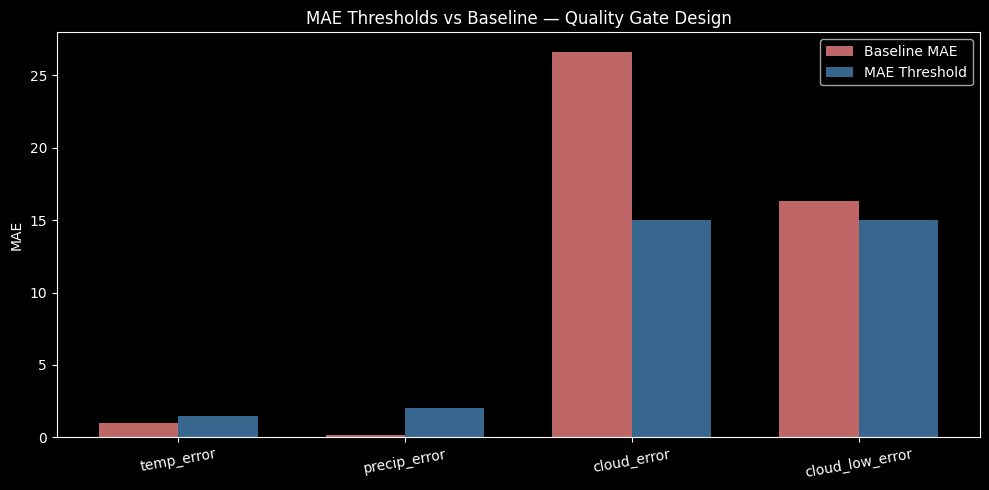

In [13]:
# 閾値の視覚化
fig, ax = plt.subplots(figsize=(10, 5))
targets = list(THRESHOLDS.keys())
baselines = [base_df[t].dropna().abs().mean() for t in targets]
thresholds = [THRESHOLDS[t] for t in targets]

x = np.arange(len(targets))
w = 0.35
ax.bar(x - w/2, baselines,   w, label="Baseline MAE", color="lightcoral", alpha=0.8)
ax.bar(x + w/2, thresholds,  w, label="MAE Threshold", color="steelblue", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(targets, rotation=10)
ax.set_ylabel("MAE")
ax.set_title("MAE Thresholds vs Baseline — Quality Gate Design")
ax.legend()
plt.tight_layout()
plt.show()

## RMSE・Bias の補助閾値設計

MAE だけでは外れ値・系統バイアスを見逃す可能性がある。
補助指標で補完する。

In [14]:
rows = []
for target, mae_thresh in THRESHOLDS.items():
    unit = TARGET_COLS[target]
    baseline_mae = base_df[target].dropna().abs().mean()
    rows.append({
        "target":        target,
        "unit":          unit,
        "① MAE 上限":    mae_thresh,
        "② RMSE 上限":   round(mae_thresh * 1.5, 2),
        "③ |bias| 上限": round(mae_thresh * 0.5, 2),
        "④ baseline":    round(baseline_mae, 3),
    })

print("モデルの値が各上限を下回れば合格（④ は baseline MAE、モデル MAE がこれを下回ること）")
display(pd.DataFrame(rows).set_index("target"))

モデルの値が各上限を下回れば合格（④ は baseline MAE、モデル MAE がこれを下回ること）


,unit,① MAE 上限,② RMSE 上限,③ |bias| 上限,④ baseline
target,,,,,
temp_error,℃,1.5000,2.2500,0.7500,1.0060
precip_error,mm,2.0000,3.0000,1.0000,0.1520
cloud_error,%,15.0000,22.5000,7.5000,26.6330
cloud_low_error,%,15.0000,22.5000,7.5000,16.2950


## 品質ゲートの検証: 学習済みモデルで実際に評価

上記で設計した閾値（`THRESHOLDS`）を使い、実際に評価フローを動かして品質ゲートの挙動を確認する。

- ルール①: `MAE < THRESHOLDS[target]`
- ルール②: `RMSE < THRESHOLDS[target] × 1.5`
- ルール③: `|bias| < THRESHOLDS[target] × 0.5`
- ルール④: `MAE < baseline_mae`（補正後が生の NWP より実値に近い）

In [15]:
LGBM_PARAMS      = load_lgbm_params()  # deployment/lgbm_params.json から読み込む
EARLY_STOPPING   = 50
VALIDATION_RATIO = 0.2

gate_results = {}

for target, unit in TARGET_COLS.items():
    df_t = features.dropna(subset=[target]).copy()
    feat_cols = get_feat_cols(df_t)
    X, y = df_t[feat_cols].fillna(0), df_t[target]

    n = len(df_t)
    split_idx = int(n * (1 - VALIDATION_RATIO))
    X_tr, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
    y_tr, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

    model = lgb.LGBMRegressor(**LGBM_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(EARLY_STOPPING, verbose=False), lgb.log_evaluation(period=0)],
    )
    y_pred = model.predict(X_val)
    m = metrics(y_val, y_pred)
    baseline_mae = float(y_val.abs().mean())

    thresh = THRESHOLDS[target]
    tests = [
        {"name": "MAE",      "ok": m["mae"] <= thresh,              "val": m["mae"],       "thresh": thresh},
        {"name": "RMSE",     "ok": m["rmse"] <= thresh * 1.5,      "val": m["rmse"],      "thresh": thresh * 1.5},
        {"name": "Bias",     "ok": abs(m["bias"]) <= thresh * 0.5, "val": abs(m["bias"]), "thresh": thresh * 0.5},
        {"name": "Baseline", "ok": m["mae"] < baseline_mae,         "val": m["mae"],       "thresh": baseline_mae},
    ]
    all_ok = all(t["ok"] for t in tests)
    gate_results[target] = {"tests": tests, "passed": all_ok, "metrics": m, "baseline_mae": baseline_mae}

    status = "✓ PASS" if all_ok else "✗ FAIL"
    print(f"[{target:20s}] {status}")
    for t in tests:
        mark = "✓" if t["ok"] else "✗"
        print(f"  {mark} {t['name']:10s}: {t['val']:.4f}  (threshold: {t['thresh']:.4f})")

[temp_error          ] ✓ PASS
  ✓ MAE       : 0.3211  (threshold: 1.5000)
  ✓ RMSE      : 0.4552  (threshold: 2.2500)
  ✓ Bias      : 0.0208  (threshold: 0.7500)
  ✓ Baseline  : 0.3211  (threshold: 1.1320)
[precip_error        ] ✓ PASS
  ✓ MAE       : 0.0748  (threshold: 2.0000)
  ✓ RMSE      : 0.4377  (threshold: 3.0000)
  ✓ Bias      : 0.0060  (threshold: 1.0000)
  ✓ Baseline  : 0.0748  (threshold: 0.1502)
[cloud_error         ] ✓ PASS
  ✓ MAE       : 6.1753  (threshold: 15.0000)
  ✓ RMSE      : 10.8949  (threshold: 22.5000)
  ✓ Bias      : 0.2224  (threshold: 7.5000)
  ✓ Baseline  : 6.1753  (threshold: 28.8314)
[cloud_low_error     ] ✓ PASS
  ✓ MAE       : 10.0074  (threshold: 15.0000)
  ✓ RMSE      : 17.1633  (threshold: 22.5000)
  ✓ Bias      : 0.3504  (threshold: 7.5000)
  ✓ Baseline  : 10.0074  (threshold: 17.2794)


## 品質ゲートの可視化

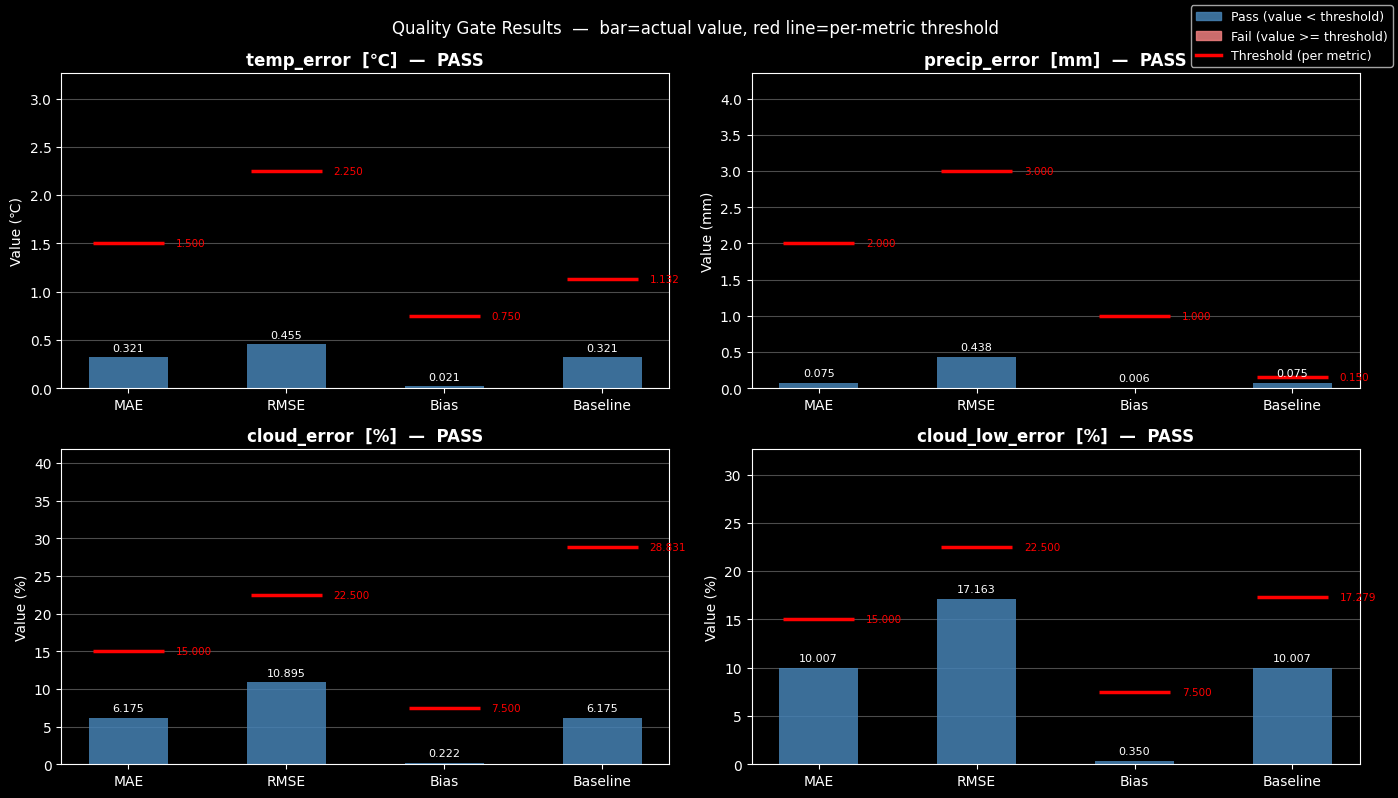

In [16]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (target, result) in zip(axes.flat, gate_results.items()):
    tests   = result["tests"]
    names   = [t["name"]   for t in tests]
    vals    = [t["val"]    for t in tests]
    threshs = [t["thresh"] for t in tests]
    colors  = ["steelblue" if t["ok"] else "lightcoral" for t in tests]

    x = np.arange(len(names))
    w = 0.5
    bars = ax.bar(x, vals, width=w, color=colors, alpha=0.85, zorder=2)

    # Per-metric threshold: red horizontal line at each bar's own threshold
    for i, thresh in enumerate(threshs):
        ax.hlines(thresh, i - w * 0.45, i + w * 0.45, colors="red", linewidths=2.5, zorder=3)
        ax.text(i + w * 0.5 + 0.05, thresh, f"{thresh:.3f}",
                color="red", va="center", ha="left", fontsize=7.5)

    # Actual value labels on top of each bar
    y_max = max(max(vals), max(threshs))
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + y_max * 0.02,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(names)
    unit = TARGET_COLS[target]
    ax.set_ylabel(f"Value ({unit})")
    ax.set_ylim(0, y_max * 1.45)
    status = "PASS" if result["passed"] else "FAIL"
    ax.set_title(f"{target}  [{unit}]  —  {status}", fontweight="bold")
    ax.grid(axis="y", alpha=0.3, zorder=0)

legend_handles = [
    mpatches.Patch(color="steelblue", alpha=0.85, label="Pass (value < threshold)"),
    mpatches.Patch(color="lightcoral", alpha=0.85, label="Fail (value >= threshold)"),
    Line2D([0], [0], color="red", linewidth=2.5, label="Threshold (per metric)"),
]
fig.legend(handles=legend_handles, loc="upper right", fontsize=9)
plt.suptitle("Quality Gate Results  —  bar=actual value, red line=per-metric threshold")
plt.tight_layout()
plt.show()

## Evidently を使った継続的評価の設計

単発の評価だけでなく、定期再学習のたびに自動評価レポートを生成する。
Evidently の採用理由:
- DataDrift: 特徴量分布のずれをモニタリング（データの質劣化を検知）
- RegressionPreset: MAE/RMSE/Bias を統一フォーマットでレポート
- HTML レポートを S3 に保存し、任意のタイミングで確認できる

### 実装の要点

1. 学習済みモデルをロード（`unwrap_python_model` で pyfunc から個別モデルを取り出す）
2. `features.parquet` の後方 20% をバリデーションセットとして使用
   - train と同じデータを使うことで、学習時の過学習と本番乖離を同時確認
3. 各ターゲットに対して評価:
   - `ref_df` = 前方 80%（train 期間相当）
   - `cur_df` = 後方 20%（val 期間相当）
   - `cur_df` に `model.predict()` を適用し MAE / RMSE / Bias を計算
   - Evidently Report（`MeanError`, `RMSE`, `MAE`, `DataDriftPreset`）を生成
   - 品質ゲート（MAE / RMSE / Bias / Baseline）を評価
4. 全ターゲット合格 → `evaluated_successful = "1"` を MLflow モデルバージョンタグに設定
5. 不合格 → `"0"` のまま → Blue/Green で旧モデルが継続稼働

**補足:**
- 分散がほぼ 0 のカラム（lag が埋まっていない箇所など）はドリフト検定から除外（`std() > 1e-6`）
  — ゼロ割り／NaN が発生してドリフト検定が無意味になるため
- `DataDriftPreset(drift_share=0.3)`: 30% 以上のカラムがドリフト → 警告
- HTML レポートは `$EVIDENTLY_WORKSPACE/{location}/{run_date}/` に保存し、MLflow artifacts にも記録

## 閾値の env var 化

閾値はコードに固定せず、環境変数で上書き可能にする。
→ location ごと・実験ごとに調整できる柔軟性を確保。

### 閾値の評価コード例

```python
import os

THRESHOLDS = {
    "temp_error":      float(os.getenv("EVIDENTLY_MAE_THRESHOLD_TEMP",   "1.5")),
    "precip_error":    float(os.getenv("EVIDENTLY_MAE_THRESHOLD_PRECIP", "2.0")),
    "cloud_error":     float(os.getenv("EVIDENTLY_MAE_THRESHOLD_CLOUD",  "15.0")),
    "cloud_low_error": float(os.getenv("EVIDENTLY_MAE_THRESHOLD_CLOUD",  "15.0")),
}

# 品質ゲート
threshold   = THRESHOLDS[target]
mae_ok      = metrics["mae"]       <= threshold
rmse_ok     = metrics["rmse"]      <= threshold * 1.5
bias_ok     = abs(metrics["bias"]) <= threshold * 0.5
baseline_ok = metrics["mae"]       < baseline_mae
passed = mae_ok and rmse_ok and bias_ok and baseline_ok
```

## まとめ: 品質ゲート最終定義

以下を実装すること。

### 品質基準の優先順位

**ルール④ (MAE < baseline) が本質的な基準。**
補正後の誤差が生の NWP 予報より実値に近くなること — これがこのシステムの存在意義。

### MAE 閾値（ルール①）— 安全上限
| ターゲット | 閾値 | ベースライン | 役割 |
|-|-|-|-|
| `temp_error` | **1.5℃** | ≈1.0℃ | 安全上限。実質的な基準はルール④ |
| `precip_error` | **2.0mm** | ≈0.15mm | 安全上限。実質的な基準はルール④ |
| `cloud_error` | **15%** | ≈26.6% | ルール①自体がベースライン超えを要求 |
| `cloud_low_error` | **15%** | ≈16.3% | ルール①とルール④が二重に担保 |

### 補助閾値（ルール②③）
- RMSE < MAE_threshold × 1.5（外れ値の多いモデルを排除）
- |bias| < MAE_threshold × 0.5（系統バイアスの上限）

### ベースライン比較（ルール④）— 実質的な番人
- MAE < baseline（補正後が生の NWP より実値に近い）

### 自動評価フレームワーク
- Evidently で HTML レポート生成（DataDrift + Regression metrics）
- 全ゲート合格 → `evaluated_successful = "1"` → Blue/Green で切替候補に
- 不合格 → `"0"` のまま → 旧モデルが継続稼働

→ 実装は `src/apps/evaluate_and_promote.py` を参照。